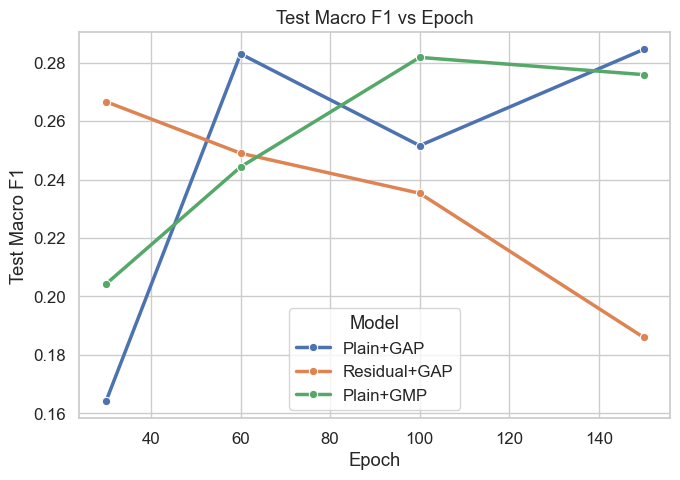

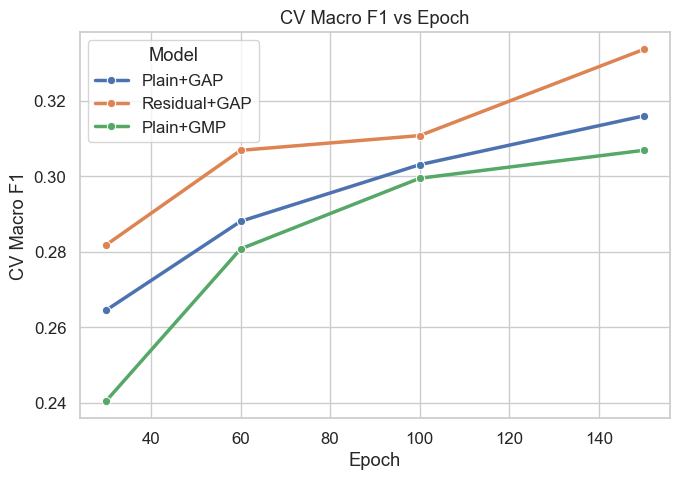

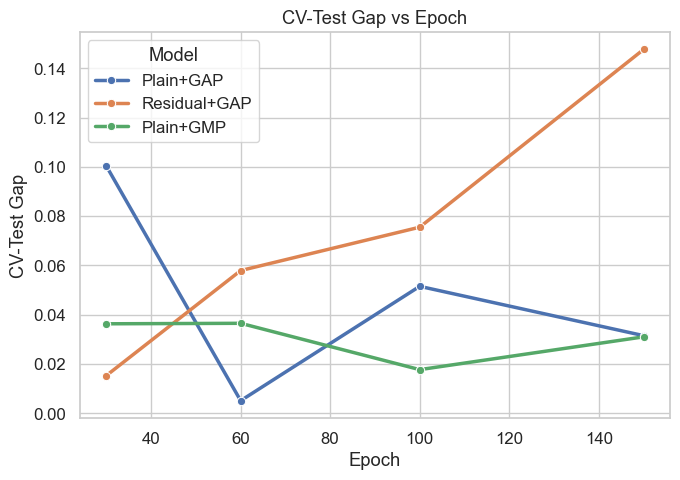

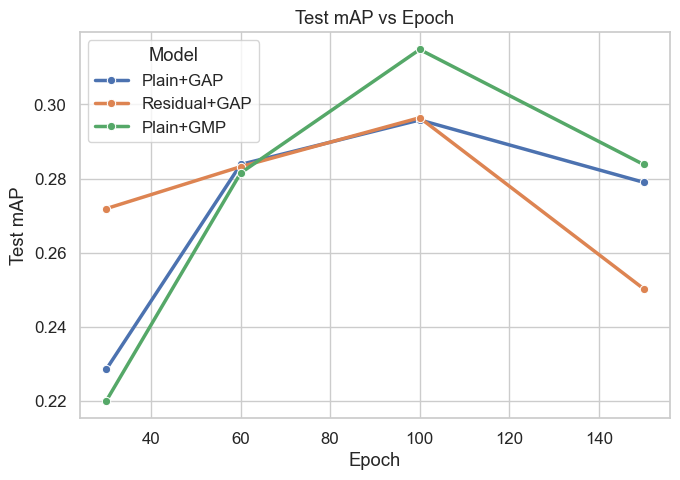

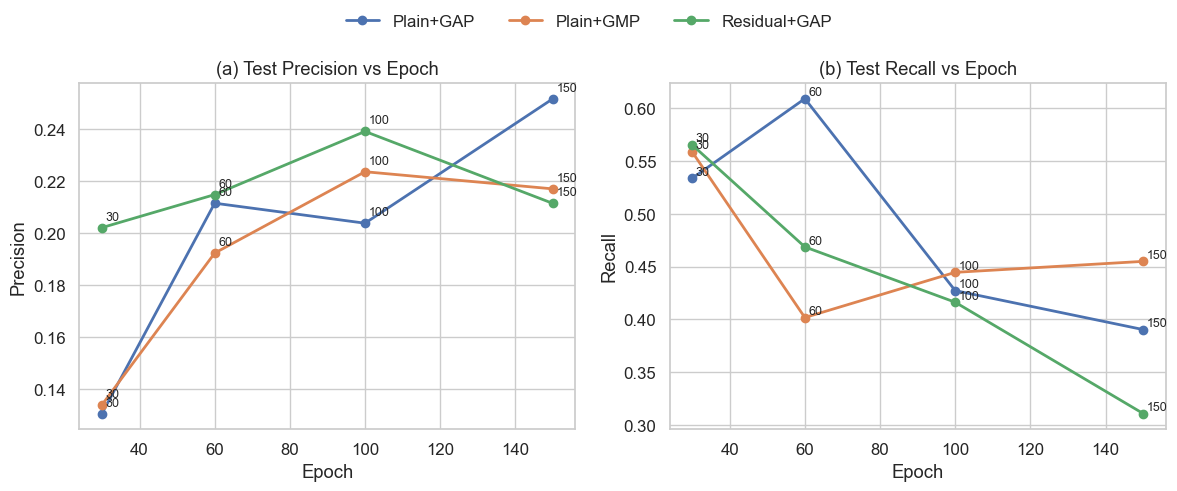

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("summary.xlsx")
df["Gap"] = df["CVMacro"] - df["TestMacro"]
df["Epoch"] = df["Epoch"].astype(int)

sns.set_theme(style="whitegrid", font_scale=1.1)

def plot_metric(df, y_col, title, ylabel=None, save_path=None):
    plt.figure(figsize=(7, 5))
    ax = sns.lineplot(
        data=df,
        x="Epoch",
        y=y_col,
        hue="Model",
        marker="o",
        linewidth=2.5,
    )
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel if ylabel is not None else title)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


# 1. Test Macro F1
plot_metric(
    df,
    y_col="TestMacro",
    title="Test Macro F1 vs Epoch",
    ylabel="Test Macro F1",
    # save_path="fig2_test_macro_epoch.png",
)

# 2. CV Macro F1
plot_metric(
    df,
    y_col="CVMacro",
    title="CV Macro F1 vs Epoch",
    ylabel="CV Macro F1",
    # save_path="fig3_cv_macro_epoch.png",
)

# 3. CV-Test Gap
plot_metric(
    df,
    y_col="Gap",
    title="CV-Test Gap vs Epoch",
    ylabel="CV-Test Gap",
    # save_path="fig4_cv_test_gap.png",
)

# 4. Test mAP
plot_metric(
    df,
    y_col="TestmAP",
    title="Test mAP vs Epoch",
    ylabel="Test mAP",
    # save_path="fig_test_map_epoch.png",
)


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

for model, sub in df.groupby("Model"):
    sub = sub.sort_values("Epoch")

    axes[0].plot(
        sub["Epoch"],
        sub["Precision"],
        marker="o",
        linewidth=2,
        label=model,
    )
    for _, row in sub.iterrows():
        axes[0].text(
            row["Epoch"] + 1,
            row["Precision"] + 0.003,
            str(int(row["Epoch"])),
            fontsize=9,
        )

    axes[1].plot(
        sub["Epoch"],
        sub["Recall"],
        marker="o",
        linewidth=2,
        label=model,
    )
    for _, row in sub.iterrows():
        axes[1].text(
            row["Epoch"] + 1,
            row["Recall"] + 0.003,
            str(int(row["Epoch"])),
            fontsize=9,
        )

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Precision")
axes[0].set_title("(a) Test Precision vs Epoch")

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Recall")
axes[1].set_title("(b) Test Recall vs Epoch")

# 只保留一个总图例
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend().remove()
axes[1].legend().remove()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()



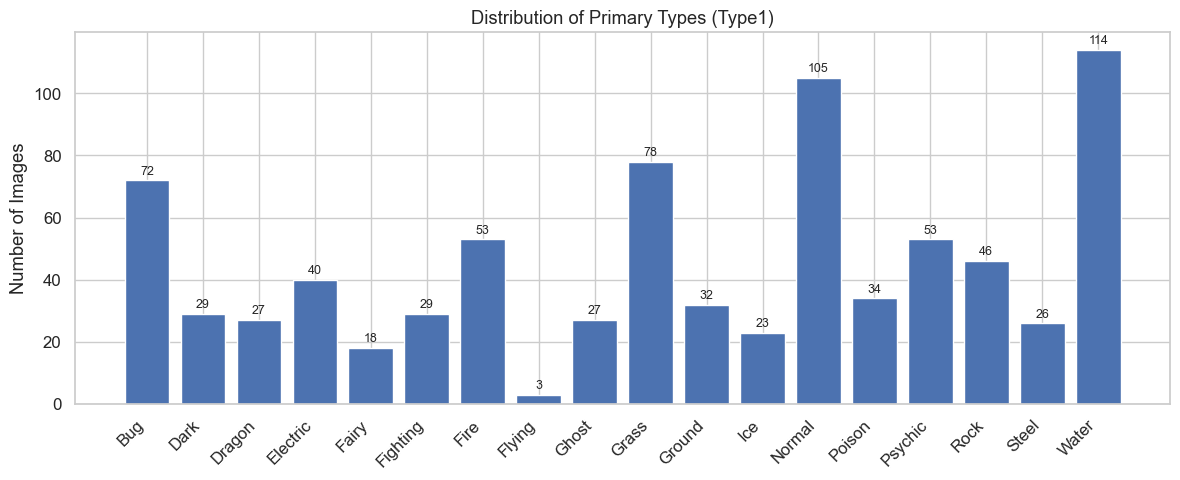

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = r"./pokemon.csv"
df = pd.read_csv(csv_path)

type1_counts = df["Type1"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
bars = plt.bar(type1_counts.index, type1_counts.values, color="#4C72B0")

for bar, value in zip(bars, type1_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        str(value),
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Images")
plt.title("Distribution of Primary Types (Type1)")
plt.tight_layout()
plt.savefig(r"E:\py project\DSAI5207\figures\type1_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


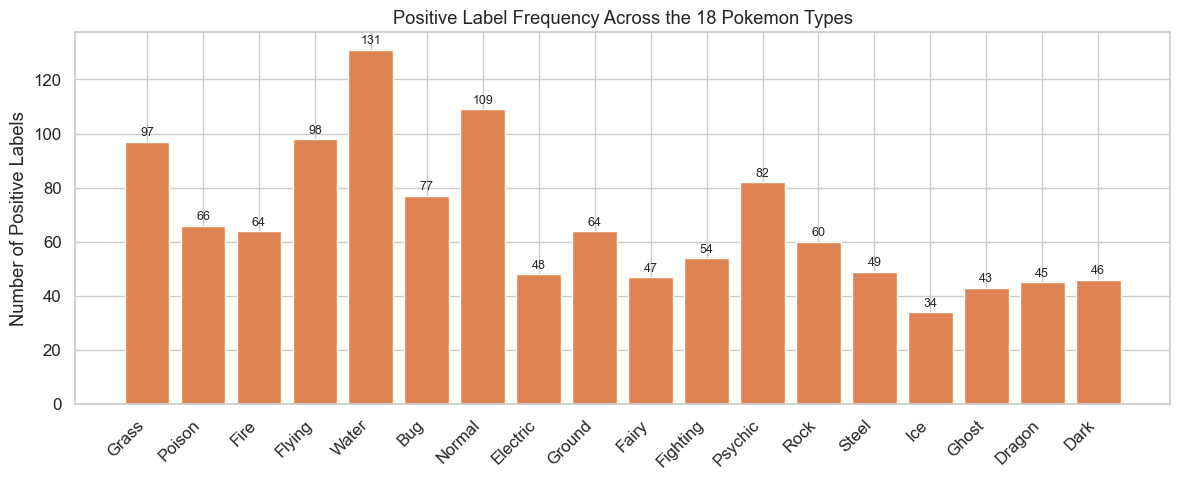

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

class_names = [
    "Grass", "Poison", "Fire", "Flying", "Water", "Bug", "Normal", "Electric",
    "Ground", "Fairy", "Fighting", "Psychic", "Rock", "Steel", "Ice", "Ghost",
    "Dragon", "Dark"
]

counts = Counter()
for _, row in df.iterrows():
    counts[row["Type1"]] += 1
    t2 = row["Type2"]
    if isinstance(t2, str) and t2.strip():
        counts[t2] += 1

values = [counts[c] for c in class_names]

plt.figure(figsize=(12, 5))
bars = plt.bar(class_names, values, color="#DD8452")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        str(value),
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Positive Labels")
plt.title("Positive Label Frequency Across the 18 Pokemon Types")
plt.tight_layout()
plt.savefig(r"E:\py project\DSAI5207\figures\multilabel_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
